# 00 — Data & Classification (Phase 1)

What the pipeline produced, whether the labels are right, and whether the class
balance can support conditioning in Phase 2.

```bash
python -m src.data.download      # artwork + species metadata (cached)
python -m src.data.bulbapedia    # scrape the design-origin taxonomy
python -m src.data.taxonomy      # species -> category, self-verifying
python -m src.data.preprocess    # -> data/processed/256/ + manifest.csv
```

In [1]:
import sys, csv
sys.path.insert(0, "..")
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from src.config import processed_dir

ROOT = processed_dir(256, tight_crop=True)
rows = list(csv.DictReader(open(ROOT / "manifest.csv", encoding="utf-8")))
kept = [r for r in rows if r["kept"] == "1"]
rng = np.random.default_rng(0)
print(f"processed {len(rows)}  ->  kept {len(kept)}  ({len(rows)-len(kept)} near-duplicates dropped)")

processed 2666  ->  kept 2231  (435 near-duplicates dropped)


## The number that actually matters

Shinies are recolours: they add palette diversity and **zero shape diversity**.
Anything about mode coverage or memorisation should be reasoned about against
the count of distinct *shapes*, not the count of files.

In [2]:
normal = sum(1 for r in kept if r["shiny"] == "0")
print(f"files            : {len(kept)}")
print(f"distinct shapes  : {normal}")
print(f"inflation        : {len(kept)/normal:.2f}x")

files            : 2231
distinct shapes  : 1308
inflation        : 1.71x


## Class balance

The gate for Phase 2. Conditioning needs enough images per class to learn from;
under ~50 it produces garbage for that label. Species with no coherent home are
discarded rather than pooled into a grab-bag class.

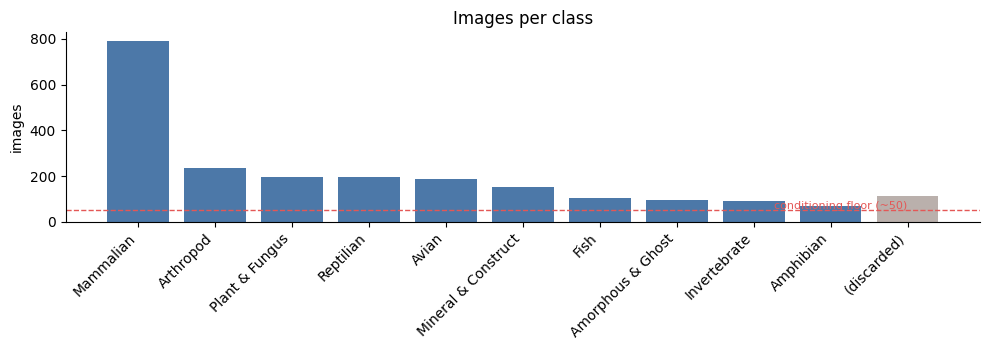

  Mammalian                789
  Arthropod                237
  Plant & Fungus           197
  Reptilian                194
  Avian                    187
  Mineral & Construct      154
  Fish                     103
  Amorphous & Ghost         96
  Invertebrate              91
  Amphibian                 71
  (discarded)              112

classes: 10   trainable: 2119/2231 (95%)   smallest: 71


In [3]:
counts = Counter(r["top"] for r in kept if r["top"])
discarded = sum(1 for r in kept if not r["top"])

names = [k for k, _ in counts.most_common()] + ["(discarded)"]
vals = [v for _, v in counts.most_common()] + [discarded]
colors = ["#4c78a8" if n >= 50 else "#e45756" for n in counts.values()] + ["#bab0ac"]

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.bar(names, vals, color=colors)
ax.axhline(50, ls="--", lw=1, c="#e45756")
ax.text(len(names) - 1, 58, "conditioning floor (~50)", ha="right", fontsize=8, color="#e45756")
ax.set_ylabel("images"); ax.set_title("Images per class")
plt.xticks(rotation=45, ha="right"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

for k, n in counts.most_common():
    print(f"  {k:<22} {n:>5}" + ("" if n >= 50 else "   <-- below floor"))
print(f"  {'(discarded)':<22} {discarded:>5}")
print(f"\nclasses: {len(counts)}   trainable: {sum(counts.values())}/{len(kept)} "
      f"({100*sum(counts.values())/len(kept):.0f}%)   smallest: {min(counts.values())}")

## Do the labels look right?

One montage per class. This is the real check — a classification that reads well
in a table can still be visibly wrong.

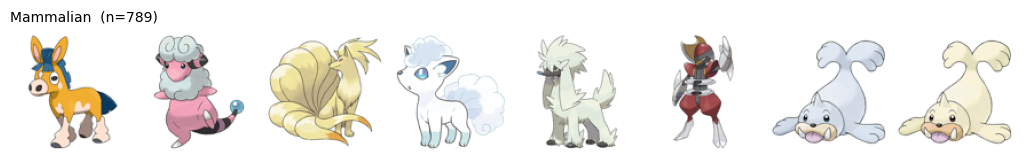

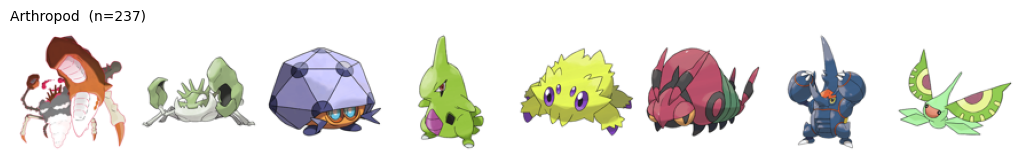

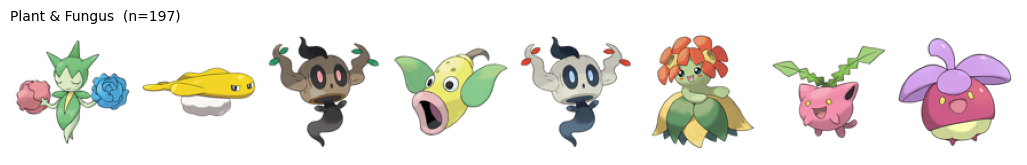

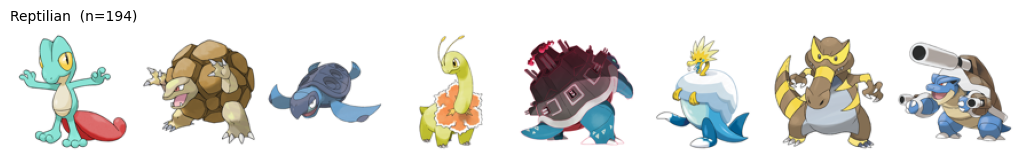

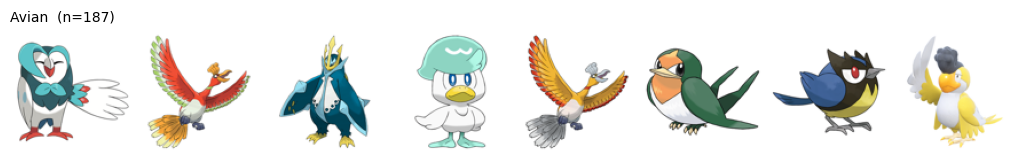

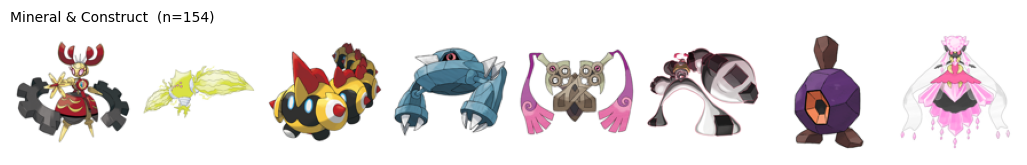

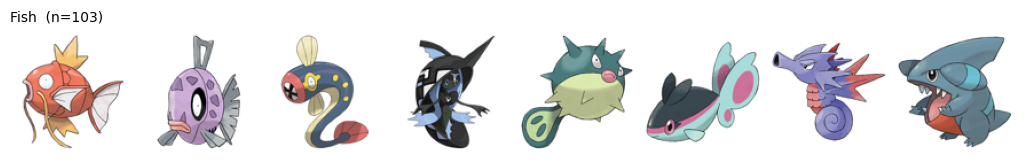

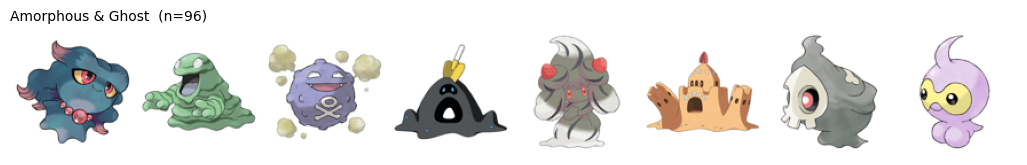

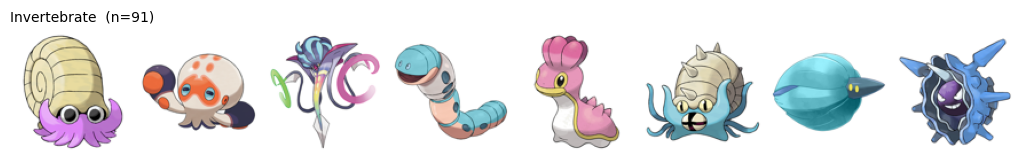

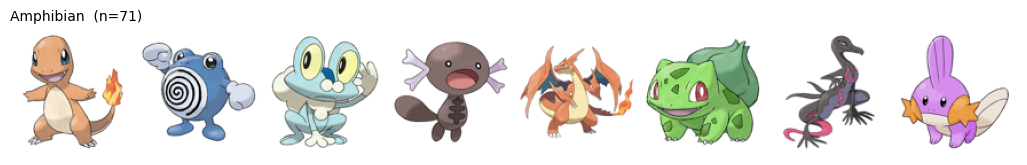

In [4]:
def montage(items, n=8, size=110):
    items = items[:n]
    sheet = Image.new("RGB", (size*len(items), size), (255, 255, 255))
    for i, r in enumerate(items):
        with Image.open(ROOT / r["file"]) as im:
            sheet.paste(im.convert("RGB").resize((size, size)), (i*size, 0))
    return sheet

by_top = defaultdict(list)
for r in kept:
    if r["top"]:
        by_top[r["top"]].append(r)

for top, n in counts.most_common():
    group = by_top[top]
    picks = [group[i] for i in rng.choice(len(group), min(8, len(group)), replace=False)]
    fig, ax = plt.subplots(figsize=(13, 1.7))
    ax.imshow(montage(picks)); ax.axis("off")
    ax.set_title(f"{top}  (n={n})", loc="left", fontsize=10)
    plt.show()

## Rehomed and discarded

The source page covers only Pokémon designed after animals or plants. What it
omits is either rehomed into a class it visually belongs to — the two classes
that exist purely for this — or discarded.

**Legendary was rejected as a class despite having 78 images**, comfortably
above the floor. Legendary is a *status*, not a look: a bird, an insect, a robot
and a rock golem share nothing visually. The 30 legendaries were assigned
individually instead, and 8 of them discarded.

discarded: 112 images



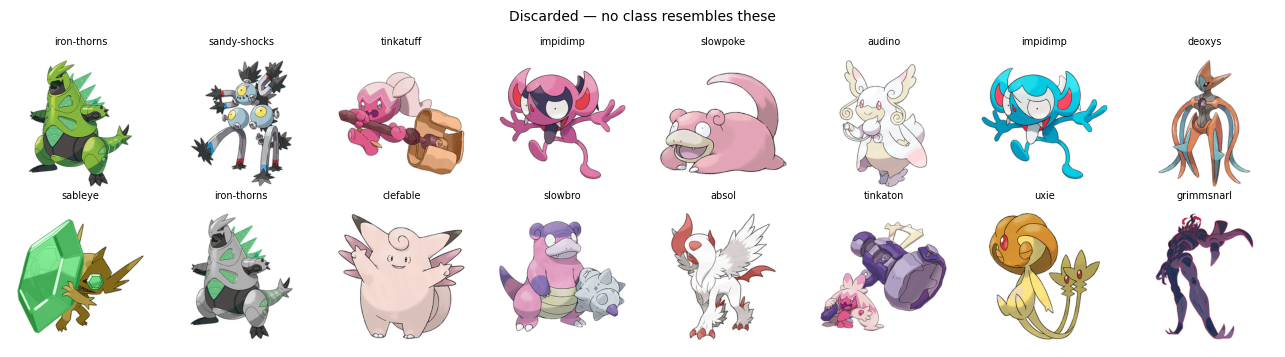

In [5]:
disc = [r for r in kept if not r["top"]]
print(f"discarded: {len(disc)} images\n")
picks = [disc[i] for i in rng.choice(len(disc), 16, replace=False)]
fig, axes = plt.subplots(2, 8, figsize=(13, 3.6))
for ax, r in zip(axes.ravel(), picks):
    with Image.open(ROOT / r["file"]) as im:
        ax.imshow(im.convert("RGB"))
    ax.axis("off"); ax.set_title(r["species"] or f"#{r['dex_id']}", fontsize=7)
plt.suptitle("Discarded — no class resembles these", fontsize=10)
plt.tight_layout(); plt.show()

## Preprocessing sanity

Every image must be 256×256 RGB, and the tight crop should have centred the
subject. If the ink centroid drifts from the middle, the crop is wrong.

sizes: {(256, 256): 2231} modes: {'RGB': 2231}


ink centroid: (31.4, 32.3) of 64  ->  offset 0.1, 0.8 px


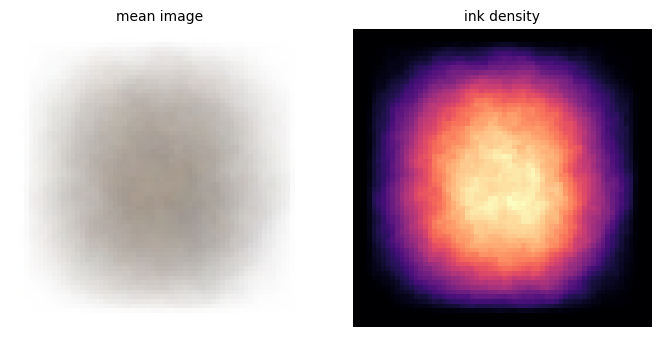

In [6]:
sizes, modes = Counter(), Counter()
for r in kept:
    with Image.open(ROOT / r["file"]) as im:
        sizes[im.size] += 1; modes[im.mode] += 1
print("sizes:", dict(sizes), "modes:", dict(modes))
assert set(sizes) == {(256, 256)} and set(modes) == {"RGB"}

sample = rng.choice(len(kept), 400, replace=False)
imgs = np.stack([
    np.asarray(Image.open(ROOT / kept[i]["file"]).convert("RGB").resize((64, 64)),
               dtype=np.float32) / 255
    for i in sample
])
m = (1 - imgs.mean(3)).mean(0); m /= m.sum()
ys, xs = np.mgrid[0:64, 0:64]
cx, cy = (xs*m).sum(), (ys*m).sum()
print(f"ink centroid: ({cx:.1f}, {cy:.1f}) of 64  ->  offset {abs(cx-31.5):.1f}, {abs(cy-31.5):.1f} px")

fig, axes = plt.subplots(1, 2, figsize=(7, 3.4))
axes[0].imshow(np.clip(imgs.mean(0), 0, 1)); axes[0].axis("off")
axes[0].set_title("mean image", fontsize=10)
axes[1].imshow(m, cmap="magma"); axes[1].axis("off")
axes[1].set_title("ink density", fontsize=10)
plt.tight_layout(); plt.show()

### Reading the mean image

A featureless blur with a faint centred mass. That is two facts at once:

1. **The crop worked** — the mass is centred and consistently scaled.
2. **Nothing else is shared** — no limbs, no faces, no canonical silhouette.
   Aligned datasets like FFHQ keep a recognisable mean face however many you
   average; here there is no template to converge on.

This is why the problem is harder than the image count suggests, and why
per-class conditioning is worth having: it gives the generator a smaller, more
coherent distribution to model at a time.

## Phase 1 gate

- download idempotent — 1,339 normal + 1,327 shiny, 434 Gen 9
- 2,231 images kept, all 256×256 RGB, subject centred
- 89% of species from a curated source; the rest rehomed or discarded
- 10 classes, 2,119 trainable images, smallest 71
- weak spots, flagged not hidden: dragons sit in Mammalian, and
  Clitellata (Onix/Steelix/Orthworm) sits in Invertebrate

Ready for Phase 2.